Estimation de l'effet causal de la fermeture des établissement 'social' sur le vote RN à l'aide d'un staggered DID

Import des bibliothèques

In [149]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from did_multiplegt_dyn import DidMultiplegtDyn  

Import des données

In [150]:
# Social
df_rnp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rnp.csv", index_col=0)
df_rnp['codecommune'] = df_rnp['codecommune'].astype(str).str.zfill(5)

df_rp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rp.csv", index_col=0)
df_rp['codecommune'] = df_rp['codecommune'].astype(str).str.zfill(5)

df_ui = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_ui.csv", index_col=0)
df_ui['codecommune'] = df_ui['codecommune'].astype(str).str.zfill(5)

df_ud = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_d.csv", index_col=0)
df_ud['codecommune'] = df_ud['codecommune'].astype(str).str.zfill(5)

C:\Users\yancr\AppData\Local\Temp\ipykernel_9960\2641705729.py:2: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rnp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rnp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_9960\2641705729.py:5: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rp = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_rp.csv", index_col=0)
C:\Users\yancr\AppData\Local\Temp\ipykernel_9960\2641705729.py:8: DtypeWarning: Columns (0: Annee) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ui = pd.read_csv(r"C:\Users\yancr\Documents\ENSAE_V2\STATAPP\V2\STATAPP_V2\Données\Partie Econometrie\communes_social_ui.csv", index_col=0)


Fonction d'attribution du traitement

In [151]:
def traitement(df):
    # 1. On définit notre seuil de traitement à partir de l'année 2002
    df_2002 = df[df['Annee'] == 1998].copy()
    df_2002['seuil'] = df_2002['total_equipements'] * 0.6

    # 2. On renseigne ce seuil dans le DataFrame pour comparer les niveaux annuels
    mapping_seuil = df_2002.set_index('codecommune')['seuil']
    df['seuil'] = df['codecommune'].map(mapping_seuil)

    # 3. Première passe : condition simple (1 si on passe sous le seuil, 0 sinon)
    df['traitée'] = (df['total_equipements'] < df['seuil']).astype(int)

    # 4. ÉTAPE CRUCIALE : Trier le tableau pour garantir l'ordre chronologique
    df = df.sort_values(by=['codecommune', 'Annee'])

    # 5. L'EFFET CLIQUET : On applique un maximum cumulé par commune.
    # Dès qu'une commune obtient un 1, toutes les lignes suivantes pour cette commune vaudront 1.
    df['traitée'] = df.groupby('codecommune')['traitée'].cummax()

    return df

## Calcul du traitement

### RNP

In [152]:
df_rnp = traitement(df_rnp)

### RP

In [153]:
df_rp = traitement(df_rp)

### UI

In [154]:
df_ui = traitement(df_ui)

### UD

In [155]:
df_ud = traitement(df_ud)

## DID

Definition du modele

In [156]:
def DID (df, election, annee_deb, parti) :
    # 1. On filtre la base pour ne garder que les années d'élection présidentielle
    annees_pres = [annee_deb, 2002, 2007, 2012, 2017, 2022]
    df_pres = df[df['Annee'].isin(annees_pres)].copy()

    # 2. Nettoyage : on retire les lignes avec des valeurs manquantes essentielles
    df_pres = df_pres.dropna(subset=[f'vote_{parti}_{election}', 'traitée'])

    # 3. On force les types en formats "simples" (Numpy) pour faciliter la conversion
    # (Cela vous évite l'erreur PyArrow)
    df_pres[f'vote_{parti}_{election}'] = df_pres[f'vote_{parti}_{election}'].astype('float64')
    df_pres['traitée'] = df_pres['traitée'].astype('float64')
    df_pres['Annee'] = df_pres['Annee'].astype('int64')
    # Note : S'il y a un souci avec 'codecommune' (par exemple si c'est un format 'object'),
    # vous pouvez aussi le forcer en string classique : df_pres['codecommune'] = df_pres['codecommune'].astype('str')

    # 4. Conversion en Polars
    df_pres_polars = pl.from_pandas(df_pres)

    # 5. Estimation Staggered DiD (avec le nom de classe corrigé)
    modele_did = DidMultiplegtDyn(
        df=df_pres_polars,         
        outcome=f'vote_{parti}_{election}',    # Variable dépendante
        group='codecommune',       # Identifiant du groupe
        time='Annee',              # Variable temporelle
        treatment='traitée',       # Indicateur de traitement
        placebo=2,                 # Tester 1 période avant le traitement (pre-trends)
        effects=5,                 # Estimer l'effet sur les 2 périodes suivant le traitement
        cluster='codecommune',      # Clustering des erreurs-types
        controls = ['pop', 'propf', 'prop014', 'prop1539', 'prop60p', 'petranger', 'pouem', 'pchom', 'paind','pbac', 'psup', 'revmoy']
    )

    modele_did.fit()
    modele_did.summary()
    modele_did.plot()
    return 

### RNP

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.000852 0.000710 -0.000539 0.002243 37217.0     4754.0 37217.0       4754.0
            Effect_2  0.004088 0.000943  0.002241 0.005935 28154.0     4241.0 28154.0       4241.0
            Effect_3  0.007969 0.001262  0.005496 0.010442 20379.0     3646.0 20379.0       3646.0
            Effect_4  0.012173 0.001701  0.008840 0.015506 13188.0     2680.0 13188.0       2680.0
            Effect_5  0.014658 0.002516  0.009727 0.019589  6196.0     1308.0  6196.0       1308.0
Average_Total_Effect  0.006148 0.000947  0.004292 0.008004 49111.0    16629.0 49111.0      16629.0
           Placebo_1  0.000349 0.000802 -0.001223 0.001922 27297.0     3401.0 27297.0       3401.0
           Placebo_2 -0.000869 0.001361 -0.003535 0.001798 12032.0     1534.0 12032.0       1534.0
Test of joint nullity of the effects: p-val

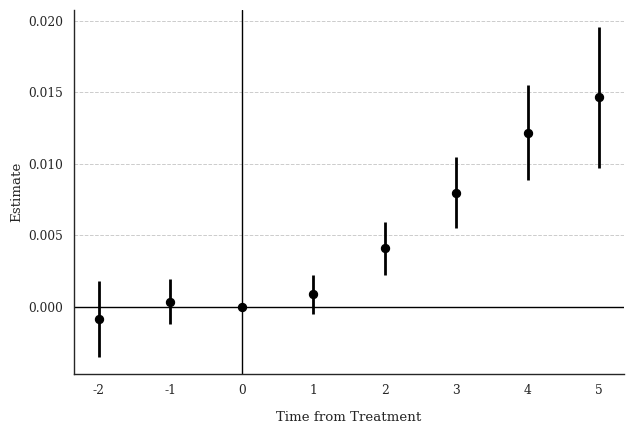

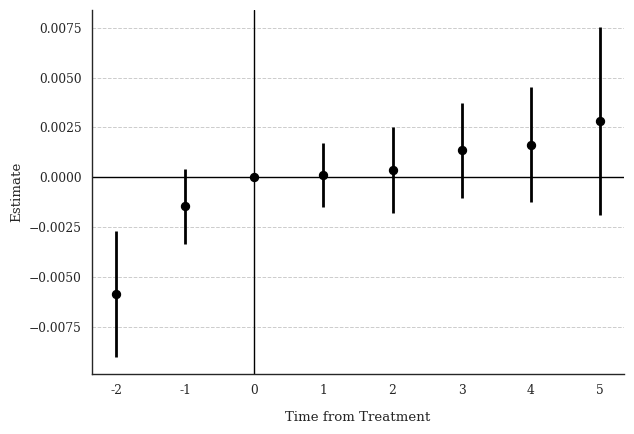

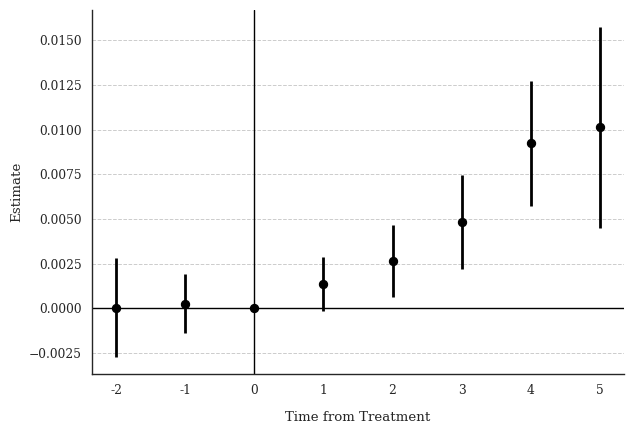

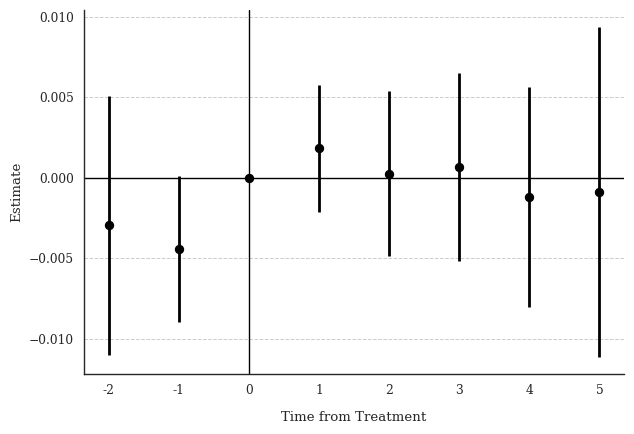

In [157]:
DID(df_rnp, 'pres', 1995, 'RN')
DID(df_rnp, 'pres', 1995, 'PS')

DID(df_rnp, 'leg', 1997, 'RN')
DID(df_rnp, 'leg', 1997, 'PS')

### RP

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI    UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.000961 0.000692 -0.000395 0.002317 34189.0     4418.0 34189.0       4418.0
            Effect_2  0.002381 0.000910  0.000597 0.004165 25954.0     4025.0 25954.0       4025.0
            Effect_3  0.003620 0.001209  0.001250 0.005990 18965.0     3516.0 18965.0       3516.0
            Effect_4  0.004869 0.001650  0.001635 0.008103 12485.0     2684.0 12485.0       2684.0
            Effect_5  0.004422 0.002374 -0.000231 0.009076  5973.0     1307.0  5973.0       1307.0
Average_Total_Effect  0.002847 0.000962  0.000961 0.004732 45729.0    15950.0 45729.0      15950.0
           Placebo_1  0.000482 0.000811 -0.001107 0.002071 25012.0     3090.0 25012.0       3090.0
           Placebo_2 -0.001062 0.001449 -0.003903 0.001778 11130.0     1331.0 11130.0       1331.0
Test of joint nullity of the effects: p-val

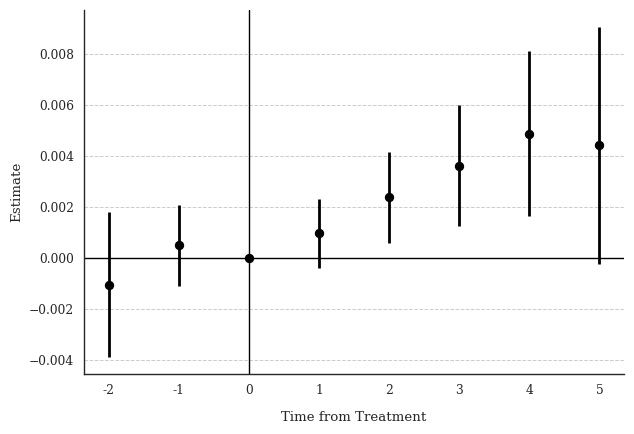

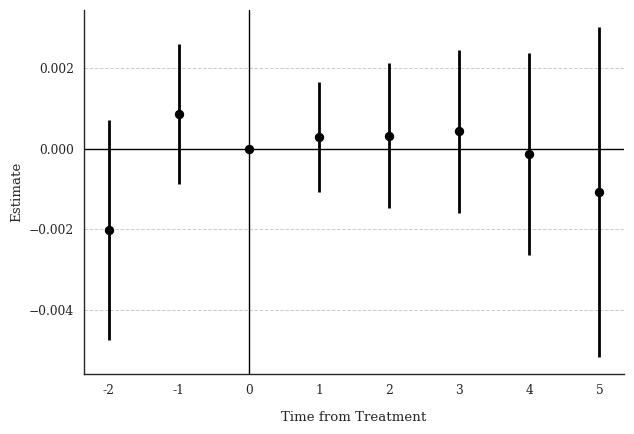

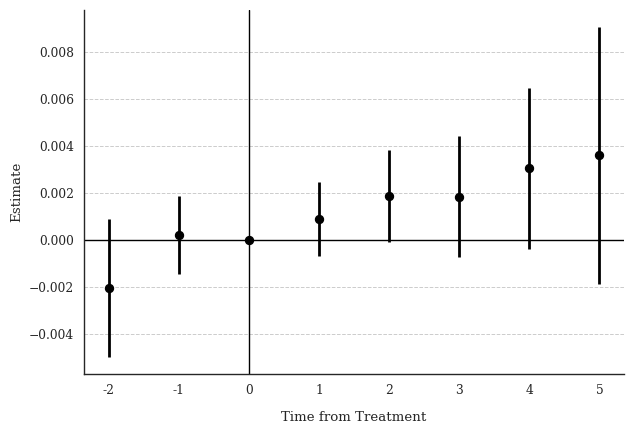

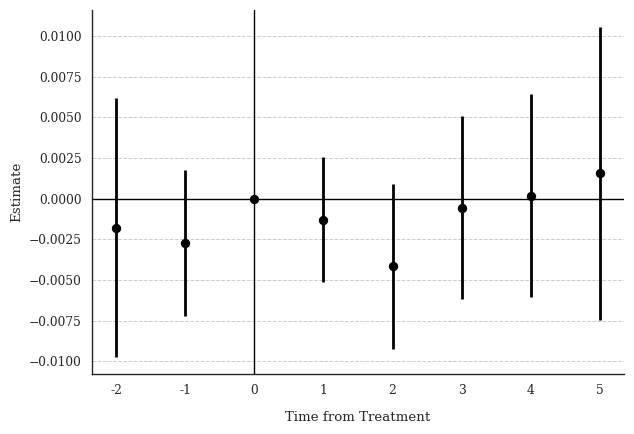

In [158]:
DID(df_rp, 'pres', 1995, 'RN')
DID(df_rp, 'pres', 1995, 'PS')

DID(df_rp, 'leg', 1997, 'RN')
DID(df_rp, 'leg', 1997, 'PS')

### UI

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI       N  Switchers     N.w  Switchers.w
            Effect_1  0.004964 0.000948  0.003106  0.006823 12130.0     1301.0 12130.0       1301.0
            Effect_2  0.009537 0.001409  0.006775  0.012300  9203.0     1181.0  9203.0       1181.0
            Effect_3  0.014151 0.002104  0.010027  0.018275  6666.0     1003.0  6666.0       1003.0
            Effect_4  0.017930 0.003008  0.012035  0.023825  4308.0      691.0  4308.0        691.0
            Effect_5  0.008936 0.004961 -0.000787  0.018658  1992.0      243.0  1992.0        243.0
Average_Total_Effect  0.010518 0.001560  0.007461  0.013574 15249.0     4419.0 15249.0       4419.0
           Placebo_1 -0.002665 0.001039 -0.004702 -0.000628  9079.0     1058.0  9079.0       1058.0
           Placebo_2 -0.008122 0.002029 -0.012099 -0.004145  4106.0      489.0  4106.0        489.0
Test of joint nullity of the effec

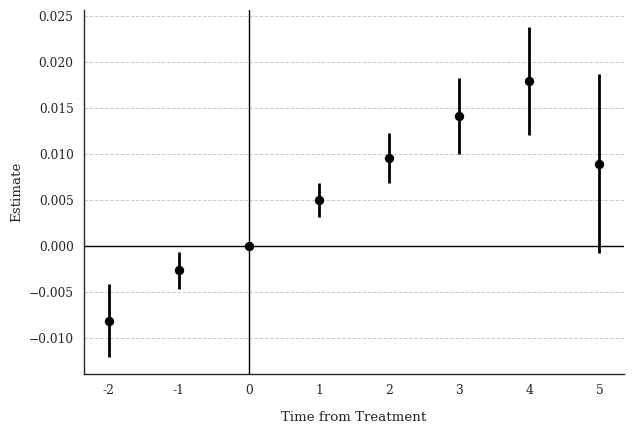

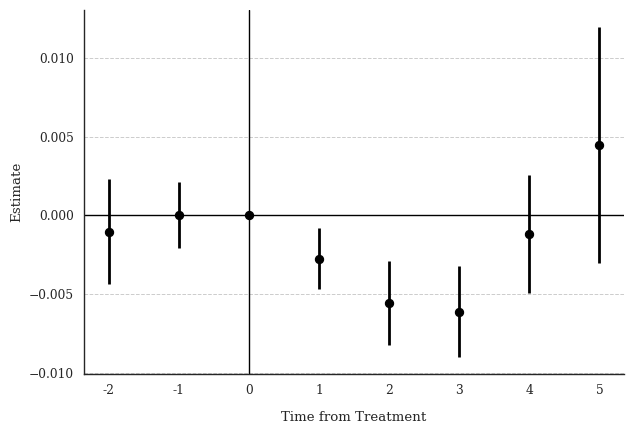

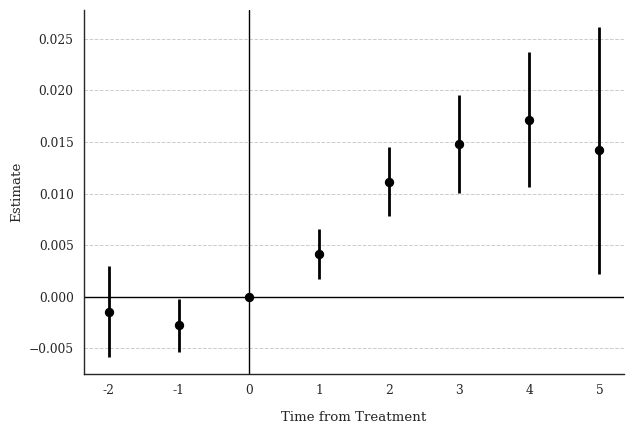

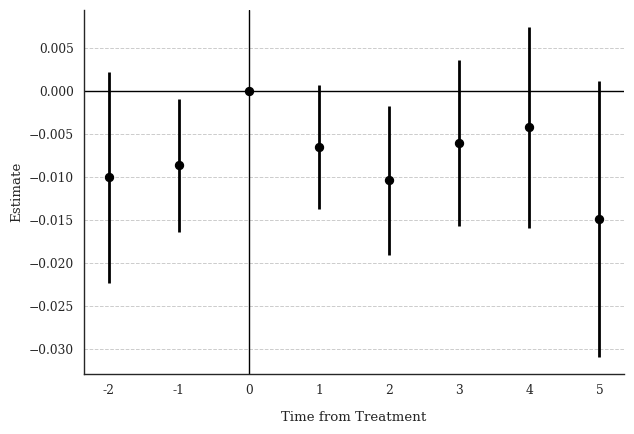

In [159]:
DID(df_ui, 'pres', 1995, 'RN')
DID(df_ui, 'pres', 1995, 'PS')

DID(df_ui, 'leg', 1997, 'RN')
DID(df_ui, 'leg', 1997, 'PS')

### UD

             Estimation of treatment effects: Event-study effects
               Block  Estimate       SE     LB CI     UB CI      N  Switchers    N.w  Switchers.w
            Effect_1  0.006332 0.002030  0.002354  0.010310 3031.0      155.0 3031.0        155.0
            Effect_2  0.020892 0.003629  0.013779  0.028006 2362.0      145.0 2362.0        145.0
            Effect_3  0.027628 0.005414  0.017016  0.038240 1731.0      116.0 1731.0        116.0
            Effect_4  0.023286 0.007103  0.009364  0.037208 1129.0       75.0 1129.0         75.0
            Effect_5  0.015519 0.015424 -0.014712  0.045750  541.0       19.0  541.0         19.0
Average_Total_Effect  0.018151 0.003556  0.011181  0.025121 3386.0      510.0 3386.0        510.0
           Placebo_1 -0.006892 0.002159 -0.011124 -0.002661 2353.0      136.0 2353.0        136.0
           Placebo_2 -0.009431 0.005328 -0.019874  0.001012 1124.0       70.0 1124.0         70.0
Test of joint nullity of the effects: p-value = 0.00

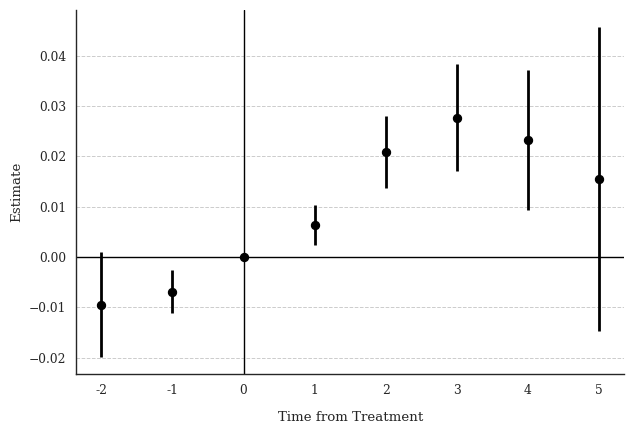

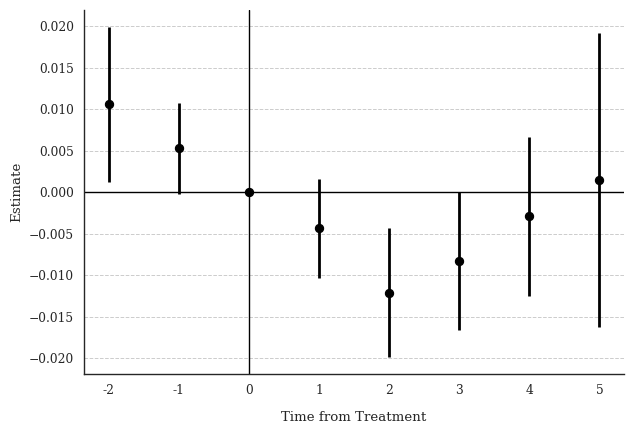

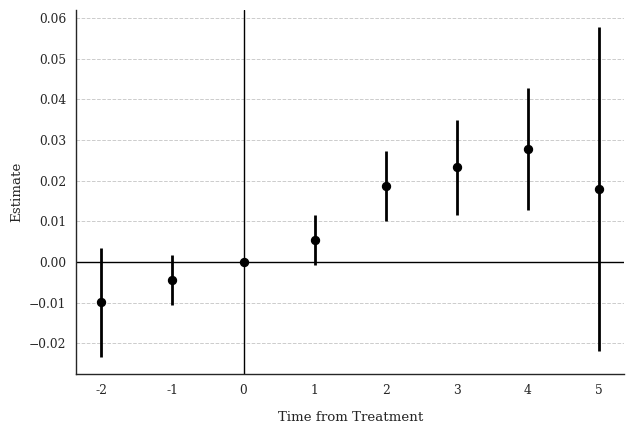

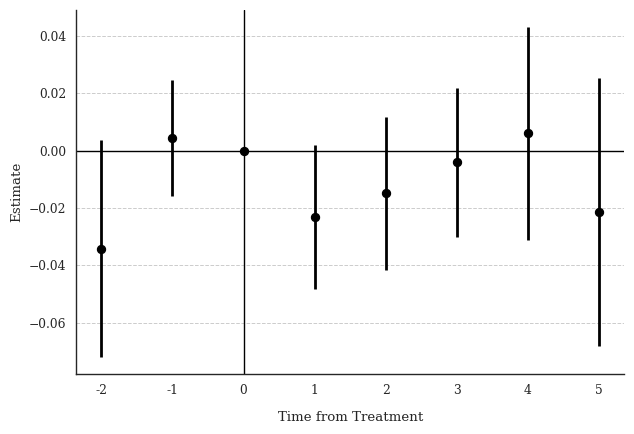

In [160]:
DID(df_ud, 'pres', 1995, 'RN')
DID(df_ud, 'pres', 1995, 'PS')

DID(df_ud, 'leg', 1997, 'RN')
DID(df_ud, 'leg', 1997, 'PS')

In [161]:
import scipy.stats as st

# Les valeurs de votre test Placebo
estimate_placebo = -0.005310 
se_placebo =  0.001607 

# 1. Calcul du Z-score
z_score = estimate_placebo / se_placebo

# 2. Calcul de la p-value bilatérale
p_value = 2 * (1 - st.norm.cdf(abs(z_score)))

print(f"Z-score : {z_score:.3f}")
print(f"P-value du Placebo : {p_value:.3f}")

Z-score : -3.304
P-value du Placebo : 0.001
